# HDFS Session Sequencer

Builds **per-block event sequences** from a parsed HDFS annotated log DataFrame.

**Input** — `*_hdfs_annotated.parquet` produced by `Parser.ipynb`  
**Output** — `*_hdfs_sequences.parquet` — flat table of all log lines with a `block_id` column, sorted by `(block_id, timestamp)`, ready for graph or model ingestion.

Each sequence is the ordered time-series of Drain template firings for one HDFS block — the unit of anomaly labelling in the benchmark.

In [2]:
import os, sys, json
import pandas as pd
from pathlib import Path

sys.path.insert(0, os.path.abspath(".."))  # project root

PROCESSED_DIR = Path("../../data/processed/hdfs")

## Step 1 — Load annotated log

Auto-picks the newest `*_hdfs_annotated.parquet` from `data/processed/`.  
Override `input_file` manually to pin a specific run.

In [3]:
candidates = sorted(PROCESSED_DIR.glob("*_hdfs_annotated.parquet"))
if not candidates:
    raise FileNotFoundError(
        f"No *_hdfs_annotated.parquet found in {PROCESSED_DIR}.\n"
        "Run Parser.ipynb first to generate the annotated log file."
    )

input_file = candidates[-1]   # newest by YYYYMMDD_HHMM prefix
# input_file = PROCESSED_DIR / "20260407_1030_hdfs_annotated.parquet"  # pin a specific run

RUN_TAG = input_file.stem.replace("_hdfs_annotated", "")
print(f"Run tag    : {RUN_TAG}")
print(f"Input file : {input_file}")

df = pd.read_parquet(input_file, engine="fastparquet")
df["parameters"] = df["parameters"].apply(json.loads)

print(f"\nRows loaded : {len(df):,}")
print(f"Columns     : {df.columns.tolist()}")
df.head(3)

Run tag    : 20260818_0002_1_parser
Input file : ../../data/processed/hdfs/20260818_0002_1_parser_hdfs_annotated.parquet

Rows loaded : 11,167,740
Columns     : ['date', 'time', 'thread', 'timestamp', 'raw', 'cluster_id', 'template', 'parameters', 'block_id']


,date,time,thread,timestamp,raw,cluster_id,template,parameters,block_id
0,081109,203518,143,2009-11-08 20:35:18,081109 203518 143 INFO dfs.DataNode$DataXceive...,1,I N F O d f s . D a t a N o d e $ D a t a X ...,"[blk_-1608999687919862906, 10.250.19.102:54106...",blk_-1608999687919862906
1,081109,203518,35,2009-11-08 20:35:18,081109 203518 35 INFO dfs.FSNamesystem: BLOCK*...,2,I N F O d f s . F S N a m e s y s t e m : ...,[/mnt/hadoop/mapred/system/job_200811092030_00...,blk_-1608999687919862906
2,081109,203519,143,2009-11-08 20:35:19,081109 203519 143 INFO dfs.DataNode$DataXceive...,1,I N F O d f s . D a t a N o d e $ D a t a X ...,"[blk_-1608999687919862906, 10.250.10.6:40524, ...",blk_-1608999687919862906


## Step 2 — Build per-block sequences

Drop lines with no `block_id` (NameNode bookkeeping lines that don't reference a specific block),  
then sort by `(block_id, timestamp)` so each group is a clean ordered time-series.

In [8]:
import time

t0 = time.time()

# Filter without .copy() — avoids duplicating the full DataFrame in memory
df_blocks = df.loc[df["block_id"].notna()].sort_values(["block_id", "timestamp"])

In [9]:
print("df_blocks type:", type(df_blocks))
print("dict:", dict, "callable:", callable(dict))
print("groupby:", df_blocks.groupby, "callable:", callable(df_blocks.groupby))

df_blocks type: <class 'pandas.core.frame.DataFrame'>
dict: <class 'dict'> callable: True
groupby: <bound method DataFrame.groupby of             date    time thread           timestamp  \
10357552  081111  094452  25370 2011-11-08 09:44:52   
10357599  081111  094452  25851 2011-11-08 09:44:52   
10357608  081111  094452  25867 2011-11-08 09:44:52   
10357670  081111  094452     30 2011-11-08 09:44:52   
10357846  081111  094454  25852 2011-11-08 09:44:54   
...          ...     ...    ...                 ...   
9853463   081111  085918     27 2011-11-08 08:59:18   
9853464   081111  085918     27 2011-11-08 08:59:18   
9928034   081111  090101     19 2011-11-08 09:01:01   
9930574   081111  090106     19 2011-11-08 09:01:06   
9973800   081111  090147     19 2011-11-08 09:01:47   

                                                        raw  cluster_id  \
10357552  081111 094452 25370 INFO dfs.DataNode$DataXcei...           1   
10357599  081111 094452 25851 INFO dfs.DataNode$DataXce

In [10]:
grouped = df_blocks.groupby(
    by="block_id",
    sort=False,
)

print(type(grouped))
print(grouped.groups.keys().__iter__().__next__())

<class 'pandas.core.groupby.generic.DataFrameGroupBy'>
blk_-1000002529962039464


In [11]:
first_group = next(iter(grouped))
print(type(first_group))
print(first_group[0])
print(first_group[1].shape)

<class 'tuple'>
blk_-1000002529962039464
(13, 9)


In [14]:


# dict(groupby) is a single pass; no per-group reset_index allocation
# (86 k groups × reset_index = 86 k DataFrame copies — the old bottleneck)
sequences = {
    block_id: group
    for block_id, group in df_blocks.groupby(
        by="block_id",
        sort=False,
    )
}

elapsed = time.time() - t0
n_dropped = len(df) - len(df_blocks)

print(f"Total log lines          : {len(df):,}")
print(f"Lines without block_id   : {n_dropped:,}  ({100 * n_dropped / len(df):.1f}%)")
print(f"Lines with block_id      : {len(df_blocks):,}")
print(f"Unique blocks            : {len(sequences):,}")
print(f"Built in                 : {elapsed:.2f}s")


Total log lines          : 11,167,740
Lines without block_id   : 0  (0.0%)
Lines with block_id      : 11,167,740
Unique blocks            : 575,061
Built in                 : 531.57s


## Step 3 — Sequence statistics

Python(99583) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(99584) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Matplotlib is building the font cache; this may take a moment.


Sequence length distribution:
count    575061.00
mean         19.42
std           5.15
min           2.00
25%          19.00
50%          19.00
75%          20.00
max         297.00

Percentiles:
  p50=19  p75=20  p90=25  p95=28  p99=32  p100=297


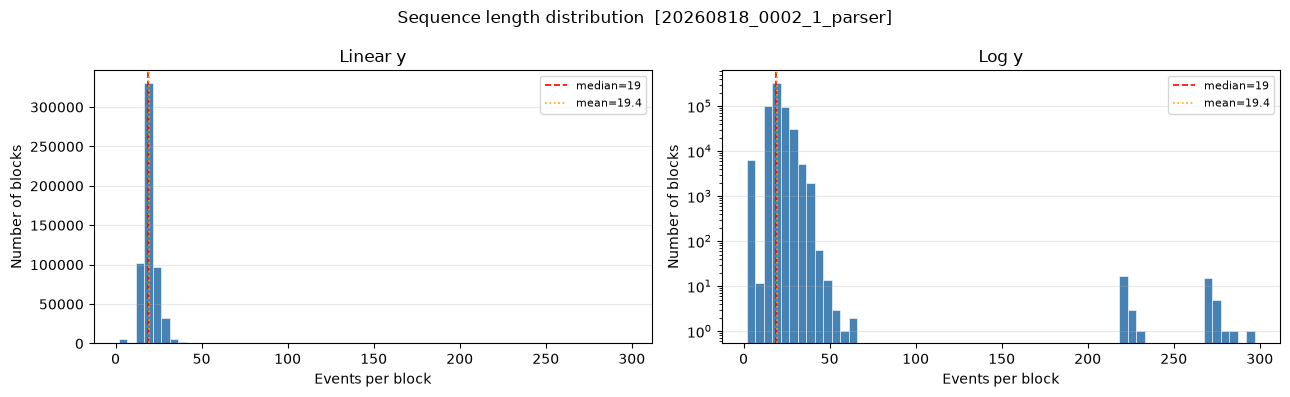

In [15]:
import numpy as np
import matplotlib.pyplot as plt

seq_lengths = pd.Series({bid: len(seq) for bid, seq in sequences.items()}, name="length")

print("Sequence length distribution:")
print(seq_lengths.describe().round(2).to_string())

print("\nPercentiles:")
pcts = [50, 75, 90, 95, 99, 100]
vals = np.percentile(seq_lengths, pcts)
print("  " + "  ".join(f"p{p}={v:.0f}" for p, v in zip(pcts, vals)))

# ── Distribution plot ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f"Sequence length distribution  [{RUN_TAG}]", fontsize=12)

for ax, log_y in zip(axes, [False, True]):
    ax.hist(seq_lengths, bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
    ax.axvline(seq_lengths.median(), color="red",    linestyle="--", linewidth=1.2,
               label=f"median={seq_lengths.median():.0f}")
    ax.axvline(seq_lengths.mean(),   color="orange", linestyle=":",  linewidth=1.2,
               label=f"mean={seq_lengths.mean():.1f}")
    ax.set_xlabel("Events per block")
    ax.set_ylabel("Number of blocks")
    ax.set_title("Linear y" if not log_y else "Log y")
    if log_y:
        ax.set_yscale("log")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Step 4 — Inspect sample sequences

In [16]:
def display_sequence(bid: str) -> None:
    """Pretty-print the ordered event sequence for a single block."""
    if bid not in sequences:
        print(f"Block '{bid}' not found.")
        return
    seq = sequences[bid]
    print("=" * 100)
    print(f"Block ID    : {bid}")
    print(f"Events      : {len(seq)}")
    print(f"Time span   : {seq['timestamp'].min()} → {seq['timestamp'].max()}")
    print("=" * 100)
    for i, row in seq.iterrows():
        print(f"  [{i:>3}] {row['timestamp']}  cid={row['cluster_id']:>3}  {row['template'][:80]}")
        if row["parameters"]:
            print(f"         params={row['parameters']}")
    print()


# Show the shortest, median, and longest sequences
sorted_bids = seq_lengths.sort_values().index.tolist()
sample_bids = {
    "shortest" : sorted_bids[0],
    "median"   : sorted_bids[len(sorted_bids) // 2],
    "longest"  : sorted_bids[-1],
}

for label, bid in sample_bids.items():
    print(f"\n{'━'*40} {label.upper()} {'━'*40}")
    display_sequence(bid)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ SHORTEST ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Block ID    : blk_-5826499677240766772
Events      : 2
Time span   : 2011-11-08 09:44:22 → 2011-11-08 09:44:22
  [10353281] 2011-11-08 09:44:22  cid=  1  I N F O   d f s . D a t a N o d e $ D a t a X c e i v e r :   R e c e i v i n g 
         params=['blk_-5826499677240766772', '10.250.14.196:42554', '10.250.14.196:50010']
  [10353331] 2011-11-08 09:44:22  cid=  2  I N F O   d f s . F S N a m e s y s t e m :   B L O C K *   N a m e S y s t e m 
         params=['/user/root/rand8/_temporary/_task_200811101024_0015_m_001464_0/part-01464.', 'blk_-5826499677240766772']


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ MEDIAN ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Block ID    : blk_-5628732165855924936
Events      : 19
Time span   : 2010-11-08 23:06:18 → 2011-11-08 04:46:31
  [5747342] 2010-11-08 23:06:18  cid=  1  I N F O   d f s . D a t a N o d e $ D a t a X c e i v e r :   R e c e i v i n g 
         

## Step 5 — Save sequences to Parquet

In [17]:
SEQUENCES_PATH = PROCESSED_DIR / f"{RUN_TAG}_3_hdfs_sequences.parquet"

df_save = df_blocks.copy()
df_save["parameters"] = df_save["parameters"].apply(json.dumps)

# Cast Arrow-backed string columns to plain numpy object (fastparquet requirement)
for col in df_save.select_dtypes(include=["object", "string"]).columns:
    df_save[col] = df_save[col].astype(object)

df_save.to_parquet(SEQUENCES_PATH, index=False, engine="fastparquet")

print(f"Saved {len(df_save):,} rows across {df_save['block_id'].nunique():,} blocks")
print(f"  → {SEQUENCES_PATH}  ({SEQUENCES_PATH.stat().st_size / 1_048_576:.1f} MB)")

# ── Reload in a later session ────────────────────────────────────────────────
# df_blocks = pd.read_parquet(SEQUENCES_PATH, engine="fastparquet")
# df_blocks["parameters"] = df_blocks["parameters"].apply(json.loads)
# sequences = {bid: grp.reset_index(drop=True) for bid, grp in df_blocks.groupby("block_id")}

Saved 11,167,740 rows across 575,061 blocks
  → ../../data/processed/hdfs/20260818_0002_1_parser_3_hdfs_sequences.parquet  (651.4 MB)
